In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.arima_process import ArmaProcess
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy import stats
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf




plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Ejercicio 1

In [2]:
z = np.arange(-15,15,0.1) # Me armo la columna desde -10 a 10

normal_n1_16 = norm.pdf(z, loc=-1, scale=4) 
normal_n1_4 = norm.pdf(z, loc=-1, scale=2)

mixtura = 0.25 * normal_n1_16 + normal_n1_4 * 0.75

pdf = pd.DataFrame({
"z": z ,
"pdf_n1_16": normal_n1_16,
"pdf_n1_4": normal_n1_4,
"pdf_mix": mixtura
})

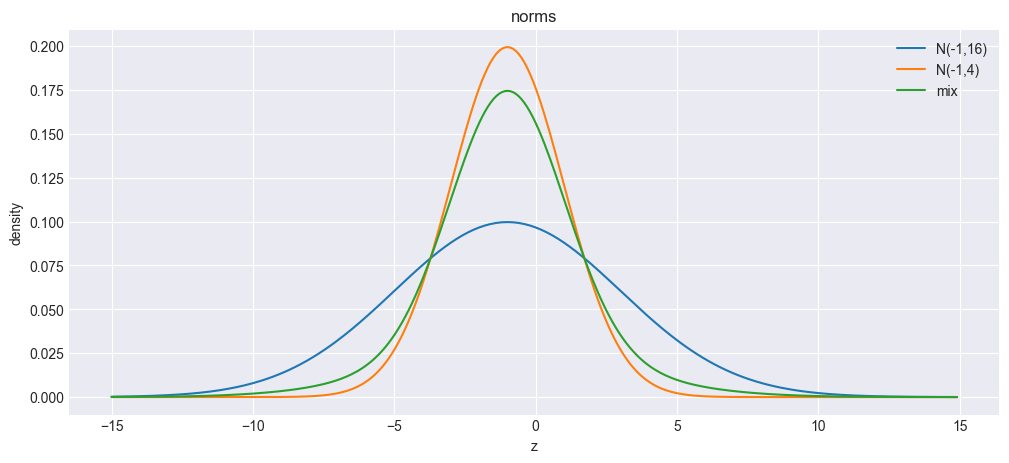

In [3]:

plt.plot(pdf['z'],pdf['pdf_n1_16'],label='N(-1,16)')
plt.plot(pdf['z'],pdf['pdf_n1_4'],label='N(-1,4)')
plt.plot(pdf['z'],pdf['pdf_mix'],label='mix')

plt.title('norms')
plt.xlabel('z')
plt.ylabel('density')
plt.legend()
plt.show()

La mixtura es completamente simetrica a simple vista. el hecho de compartir medias entre las otras dos normales (y que sean normales) hace que no haya ese problema. 

In [4]:

w1=0.25
w2=0.75
mu1 = -1
mu2= -1
var1 = 16
var2 = 4
sigma1 = np.sqrt(16)
sigma2 = np.sqrt(4)

# Media de la mixtura
media_mix = -1

# Varianza de la mixtura
var_mix = (
    w1 * (var1 + (mu1 - media_mix)**2)
    + w2 * (var2 + (mu2 - media_mix)**2)
)

# Momentos centrales 3 y 4 de la mixtura
mu3_mix = (
    w1 * ((mu1 - media_mix)**3 + 3 * (mu1 - media_mix) * var1)
    + w2 * ((mu2 - media_mix)**3 + 3 * (mu2 - media_mix) * var2)
)

mu4_mix = (
    w1 * ((mu1 - media_mix)**4 + 6 * (mu1 - media_mix)**2 * var1 + 3 * var1**2)
    + w2 * ((mu2 - media_mix)**4 + 6 * (mu2 - media_mix)**2 * var2 + 3 * var2**2)
)

asimetria = mu3_mix / (var_mix ** 1.5)
curtosis = mu4_mix / (var_mix ** 2)

print(f' Para la mixtura, la media es {media_mix} y su varianza es {var_mix} \n la asimetria es {asimetria}\n su K {curtosis}')

 Para la mixtura, la media es -1 y su varianza es 7.0 
 la asimetria es 0.0
 su K 4.653061224489796


Por lo que vemos el resultado de su curtosis. es leptocurtica, es decir que  sus colas son mas PESADAS porque aparecen mas frecuentemente los valores extremos de lo que deberia

In [ ]:
np.random.seed(103)

n = 2000

df_sim = pd.DataFrame()

df_sim["N(-1,16)"] = np.random.normal(loc=mu1, scale=np.sqrt(var1), size=n)
df_sim["N(-1,4)"] = np.random.normal(loc=mu2, scale=np.sqrt(var2), size=n)
df_sim["U"] = np.random.uniform(0, 1, size=n)

df_sim["compound_mix"] = np.where(
    df_sim["U"] < w1,
    df_sim["N(-1,16)"],
    df_sim["N(-1,4)"]

)

df_sim.head()

,"N(-1,16)","N(-1,4)",U,"N(-1,7)",compound_mix
0,-5.997113,2.653290,0.065251,-2.601856,-5.997113
1,-2.041326,-3.567321,0.699424,-0.369893,-3.567321
2,0.535173,-0.727277,0.597665,1.067393,-0.727277
3,-2.541846,1.099632,0.911796,-0.888772,1.099632
4,-5.340547,-0.622406,0.046277,-1.764268,-5.340547


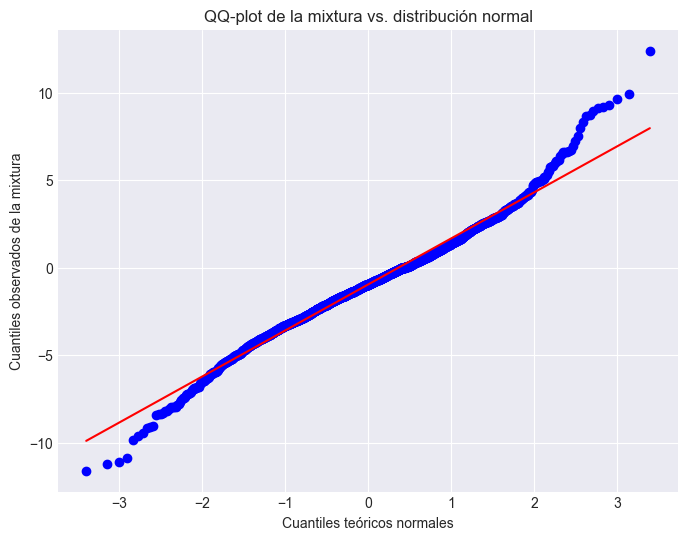

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

stats.probplot(df_sim["compound_mix"], dist="norm", plot=ax)

ax.set_title("QQ-plot de la mixtura vs. distribución normal")
ax.set_xlabel("Cuantiles teóricos normales")
ax.set_ylabel("Cuantiles observados de la mixtura")
plt.show()

# Ejercicio 2

In [17]:
ruta = "/Users/bautistagianfrancisco/Library/Mobile Documents/com~apple~CloudDocs/MIA 2026/2 Trim/Modelado Estocastico/Bases de Datos MIA103/tasas_macro.xlsx"

tasas = pd.read_excel(
    ruta,
    sheet_name='Sheet1'
)

tasas.head()

,mes,spread,d_short
0,2004-01,1.3863,0.3641
1,2004-02,2.0306,0.3491
2,2004-03,2.4826,0.3069
3,2004-04,2.7144,0.4234
4,2004-05,2.3960,0.5418


In [ ]:
# Me paso la columna Mes al indice y la pongo en datetime 

tasas["mes"] = pd.to_datetime(tasas["mes"])
tasas = tasas.set_index("mes")


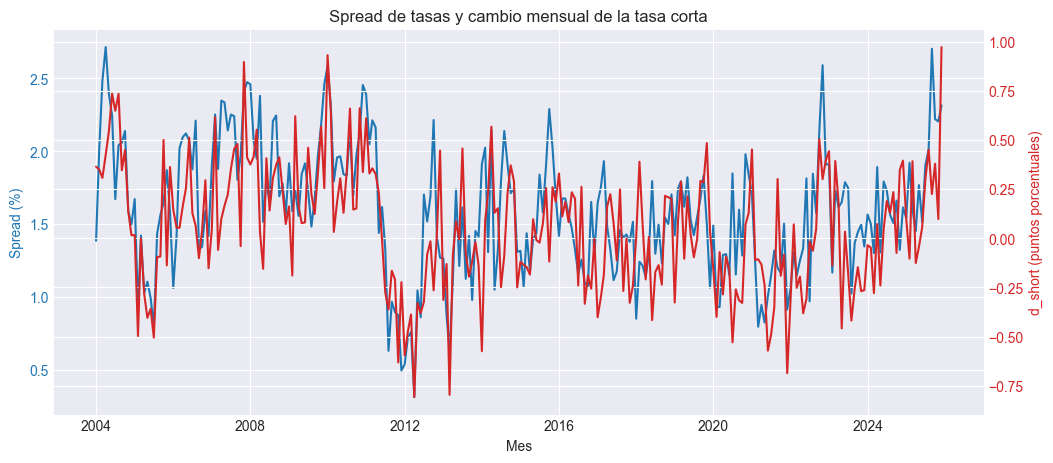

In [21]:
#Hago el sibplot

fig, ax1 = plt.subplots()

ax1.plot(tasas.index, tasas["spread"], color="tab:blue", label="Spread")
ax1.set_xlabel("Mes")
ax1.set_ylabel("Spread (%)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(tasas.index, tasas["d_short"], color="tab:red", label="Cambio tasa corta")
ax2.set_ylabel("d_short (puntos porcentuales)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Spread de tasas y cambio mensual de la tasa corta")
plt.show()


In [20]:
tasas.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 264 entries, 2004-01-01 to 2025-12-01
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   spread   264 non-null    float64
 1   d_short  264 non-null    float64
dtypes: float64(2)
memory usage: 6.2 KB


In [22]:
y1 = tasas['spread']

test_adf = adfuller(
    y1,
    regression="c",
    autolag="BIC",
)

print("Estadístico ADF:", test_adf[0])
print("p-value:", test_adf[1])
print("Cantidad de rezagos elegida por BIC:", test_adf[2])
print("Valores críticos:", test_adf[4])

Estadístico ADF: -4.827009416119276
p-value: 4.8271957726761435e-05
Cantidad de rezagos elegida por BIC: 1
Valores críticos: {'1%': np.float64(-3.455558114028747), '5%': np.float64(-2.872635586277424), '10%': np.float64(-2.572682677000175)}


spread: ADF = −4.8270, p-value = 0.000048, con 1 rezago elegido por BIC. Como el p-value es menor a 0.05 —y el estadístico es más negativo que el valor crítico al 5% (−2.8726)— rechazás la hipótesis nula de raíz unitaria. spread es estacionaria, \(I(0)\).

In [23]:
y2 = tasas['d_short']

test_adf = adfuller(
    y2,
    regression="c",
    autolag="BIC",
)

print("Estadístico ADF:", test_adf[0])
print("p-value:", test_adf[1])
print("Cantidad de rezagos elegida por BIC:", test_adf[2])
print("Valores críticos:", test_adf[4])

Estadístico ADF: -5.905255568806036
p-value: 2.7181649684028596e-07
Cantidad de rezagos elegida por BIC: 1
Valores críticos: {'1%': np.float64(-3.455558114028747), '5%': np.float64(-2.872635586277424), '10%': np.float64(-2.572682677000175)}


d_short: ADF = −5.9053, p-value ≈ 0.00000027, con 1 rezago elegido por BIC. También rechazás raíz unitaria. d_short es estacionaria, \(I(0)\).

In [24]:
# Al ser las dos I(0) lo puedo hacer con tranquilidad. 

modelo_var = VAR(tasas[["spread", "d_short"]])

seleccion_rezagos = modelo_var.select_order(maxlags=12)

print(seleccion_rezagos.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -4.521      -4.493     0.01087      -4.510
1       -5.165      -5.081    0.005714      -5.131
2      -5.269*     -5.129*   0.005150*     -5.212*
3       -5.253      -5.057    0.005230      -5.175
4       -5.232      -4.980    0.005344      -5.130
5       -5.224      -4.916    0.005385      -5.100
6       -5.199      -4.835    0.005524      -5.052
7       -5.190      -4.770    0.005572      -5.021
8       -5.201      -4.725    0.005512      -5.010
9       -5.176      -4.643    0.005656      -4.961
10      -5.154      -4.566    0.005778      -4.918
11      -5.140      -4.496    0.005864      -4.881
12      -5.130      -4.430    0.005924      -4.848
--------------------------------------------------


/Users/bautistagianfrancisco/Library/Mobile Documents/com~apple~CloudDocs/MIA 2026/2 Trim/Modelado Estocastico/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Bueno veo la salida y evidentemente tiene que ser con dos lags

In [26]:
p = seleccion_rezagos.selected_orders["bic"]

resultado_var = modelo_var.fit(p, trend="c")

print(resultado_var.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 28, Aug, 2026
Time:                     23:20:33
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -5.13216
Nobs:                     262.000    HQIC:                  -5.21361
Log likelihood:          -43.3697    FPE:                 0.00515214
AIC:                     -5.26835    Det(Omega_mle):      0.00496098
--------------------------------------------------------------------
Results for equation spread
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const              0.464854         0.115528            4.024           0.000
L1.spread          0.488248         0.065900            7.409           0.000
L1.d_short         0.023775         0.088078            0.270          

In [27]:
resultado_var.is_stable()

np.True_

In [28]:
residuos = pd.DataFrame(
    resultado_var.resid,
    columns=["spread", "d_short"]
)

for columna in residuos.columns:
    lb = acorr_ljungbox(
        residuos[columna],
        lags=[12],
        return_df=True
    )
    print(f"\nLjung-Box para residuos de {columna}:")
    print(lb)


Ljung-Box para residuos de spread:
      lb_stat  lb_pvalue
12  12.130894   0.435225

Ljung-Box para residuos de d_short:
     lb_stat  lb_pvalue
12  9.964319   0.619091


No tengo la suficiente informacion para rechazar a nivel 5% y decir que existe autocorrelacion en los 12 resagos

In [29]:
# H0: los rezagos de spread NO ayudan a predecir d_short
granger_spread_a_dshort = resultado_var.test_causality(
    caused="d_short",
    causing="spread",
    kind="f"
)

print("¿spread causa a d_short en el sentido de Granger?")
print(granger_spread_a_dshort.summary())


# H0: los rezagos de d_short NO ayudan a predecir spread
granger_dshort_a_spread = resultado_var.test_causality(
    caused="spread",
    causing="d_short",
    kind="f"
)

print("¿d_short causa a spread en el sentido de Granger?")
print(granger_dshort_a_spread.summary())

¿spread causa a d_short en el sentido de Granger?
Granger causality F-test. H_0: spread does not Granger-cause d_short. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value         df        
--------------------------------------------------------
         32.68          3.013   0.000 (2, np.int64(514))
--------------------------------------------------------
¿d_short causa a spread en el sentido de Granger?
Granger causality F-test. H_0: d_short does not Granger-cause spread. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value         df        
--------------------------------------------------------
        0.7922          3.013   0.453 (2, np.int64(514))
--------------------------------------------------------


### c. Causalidad de Granger

Se analiza la causalidad de Granger usando el VAR(2) seleccionado previamente mediante el criterio BIC.

El test evalúa si los rezagos de una variable aportan información para predecir a la otra, una vez considerados los propios rezagos de la variable a predecir.

| Dirección analizada | Hipótesis nula | Estadístico F | p-value | Conclusión |
|---|---|---:|---:|---|
| `spread → d_short` | El spread no causa a `d_short` en el sentido de Granger | 32.68 | < 0.001 | Se rechaza \(H_0\) |
| `d_short → spread` | `d_short` no causa al spread en el sentido de Granger | 0.7922 | 0.453 | No se rechaza \(H_0\) |

Por lo tanto, existe evidencia estadística de que el **spread de tasas ayuda a anticipar los cambios mensuales de la tasa de interés de corto plazo**. En cambio, no existe evidencia de que los cambios pasados de la tasa corta ayuden a anticipar el spread.

La interpretación económica es que el spread contiene información sobre las expectativas del mercado acerca de la evolución futura de la tasa de corto plazo. Una curva de tasas con mayor o menor pendiente anticipa movimientos posteriores de dicha tasa. Sin embargo, este resultado representa una relación predictiva y no necesariamente una relación causal estructural.

# Ejercicio 3



In [31]:
# Ejercicio 3: proceso ARMA(2,1)

arparams = np.array([1.2, -0.32])
maparams = np.array([0.75])

# Statsmodels exige incluir el lag 0 y cambiar el signo de AR
ar = np.r_[1, -arparams]
ma = np.r_[1, maparams]

arma_process = ArmaProcess(ar, ma)

print("¿Es estacionario?", arma_process.isstationary)
print("¿Es invertible?", arma_process.isinvertible)

raices_ar = arma_process.arroots
raices_ma = arma_process.maroots

print("Raíces del polinomio AR:", raices_ar)
print("Raíces del polinomio MA:", raices_ma)

print("Primeros 5 valores de la impulso-respuesta:")
print(arma_process.impulse_response(5))

¿Es estacionario? True
¿Es invertible? True
Raíces del polinomio AR: [1.25 2.5 ]
Raíces del polinomio MA: [-1.33333333]
Primeros 5 valores de la impulso-respuesta:
[1.     1.95   2.02   1.8    1.5136]
